In [6]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense,Bidirectional,SimpleRNN,LSTM,GRU,Embedding
from tensorflow.keras.models import Sequential

In [3]:
# load the IMDB dataset
num_words = 10000
(X_train,y_train),(X_test,y_test) = imdb.load_data(num_words=num_words)

In [4]:
# Pad sequences
maxlen=100 # maximum sequence length
X_train = pad_sequences(X_train,maxlen=maxlen,padding='post',truncating='post')
X_test = pad_sequences(X_test,maxlen=maxlen,padding='post',truncating='post')

In [19]:
# Building the unidirectional RNN model
embedding_dim = 32 # Dimension of embedding layer

model1 = Sequential()

model1.add(Embedding(input_dim = num_words, output_dim = embedding_dim, input_shape=(maxlen,)))
model1.add(SimpleRNN(5)), # 5 RNN unilts

model1.add(Dense(1,activation='sigmoid')) 

model1.summary()

model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 5)              │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,196 (1.22 MB)

 Trainable params: 320,196 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history1 = model1.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5087 - loss: 0.6961 - val_accuracy: 0.5098 - val_loss: 0.6958
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6822 - loss: 0.6162 - val_accuracy: 0.5052 - val_loss: 0.7480
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7999 - loss: 0.4610 - val_accuracy: 0.5018 - val_loss: 0.8666
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8640 - loss: 0.3450 - val_accuracy: 0.5062 - val_loss: 0.9941
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8972 - loss: 0.2755 - val_accuracy: 0.5068 - val_loss: 1.1364


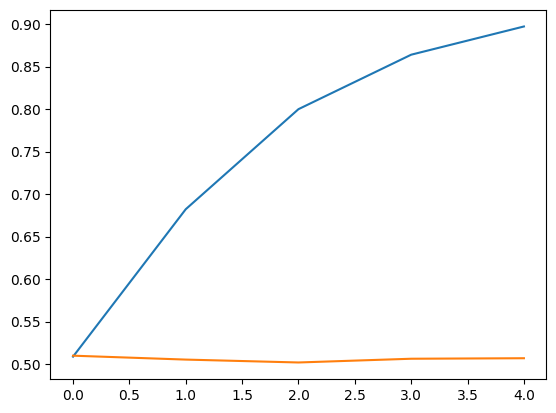

In [23]:
plt.plot(history1.history['accuracy'],label='accuracy')
plt.plot(history1.history['val_accuracy'],label='validation_accuracy')

In [12]:
model2 = Sequential()

model2.add(Embedding(input_dim=num_words,output_dim=embedding_dim,input_shape=(maxlen,)))
model2.add(Bidirectional(SimpleRNN(5)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10)             │           380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,391 (1.22 MB)

 Trainable params: 320,391 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history2 = model2.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5339 - loss: 0.6881 - val_accuracy: 0.5732 - val_loss: 0.6780
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7545 - loss: 0.5350 - val_accuracy: 0.7258 - val_loss: 0.5543
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8947 - loss: 0.2862 - val_accuracy: 0.7652 - val_loss: 0.5488
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9493 - loss: 0.1614 - val_accuracy: 0.7432 - val_loss: 0.6058
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9761 - loss: 0.0926 - val_accuracy: 0.7458 - val_loss: 0.6723


In [21]:
import matplotlib.pyplot as plt

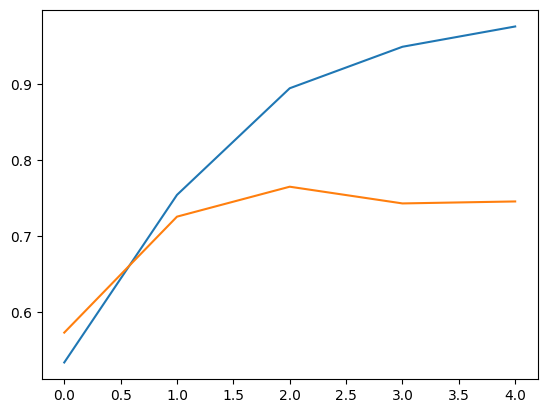

In [22]:
plt.plot(history2.history['accuracy'],label='accuracy')
plt.plot(history2.history['val_accuracy'],label='validation_accuracy')

In [14]:
model3 = Sequential()

model3.add(Embedding(input_dim=num_words,output_dim=embedding_dim,input_shape=(maxlen,)))
model3.add(Bidirectional(LSTM(5)))
model3.add(Dense(1,activation='sigmoid'))

model3.summary()

model3.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 10)             │         1,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,531 (1.23 MB)

 Trainable params: 321,531 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history3 = model3.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7416 - loss: 0.5191 - val_accuracy: 0.8054 - val_loss: 0.4400
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8656 - loss: 0.3256 - val_accuracy: 0.8276 - val_loss: 0.3868
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9079 - loss: 0.2418 - val_accuracy: 0.8236 - val_loss: 0.4123
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9344 - loss: 0.1815 - val_accuracy: 0.8216 - val_loss: 0.4621
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9524 - loss: 0.1326 - val_accuracy: 0.7960 - val_loss: 0.5734


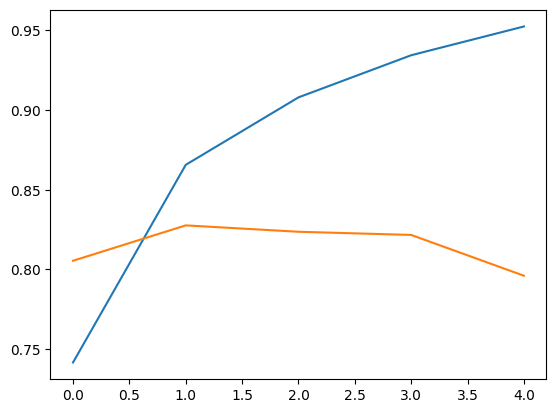

In [24]:
plt.plot(history3.history['accuracy'],label='accuracy')
plt.plot(history3.history['val_accuracy'],label='validation_accuracy')

In [16]:
model4 = Sequential()

model4.add(Embedding(input_dim=num_words,output_dim=embedding_dim,input_shape=(maxlen,)))
model4.add(Bidirectional(GRU(5)))
model4.add(Dense(1,activation='sigmoid'))
model4.summary()

model4.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 10)             │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,181 (1.23 MB)

 Trainable params: 321,181 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history4 = model4.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6937 - loss: 0.5625 - val_accuracy: 0.8048 - val_loss: 0.4324
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8599 - loss: 0.3369 - val_accuracy: 0.8276 - val_loss: 0.3862
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9054 - loss: 0.2433 - val_accuracy: 0.8292 - val_loss: 0.4209
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9413 - loss: 0.1628 - val_accuracy: 0.8244 - val_loss: 0.4983
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9667 - loss: 0.1046 - val_accuracy: 0.8118 - val_loss: 0.5834


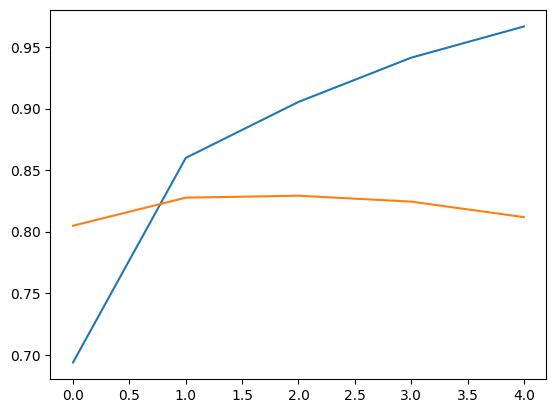

In [25]:
plt.plot(history4.history['accuracy'],label='accuracy')
plt.plot(history4.history['val_accuracy'],label='validation_accuracy')